# Setup

## Packages

In [ ]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import numpy as np
import scipy as sp
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib import patches
from matplotlib.path import Path
import matplotlib.patches as mpatches
import seaborn as sns

## Functions

### Shuffled embedding

In [ ]:
def embedding_shuffled(
    adata,
    basis="X_umap",
    legend_fontsize=12,
    legend_fontoutline=3,
    add_outline=False,
    frameon=False,
    size=None,
    show=False,
    *args,
    **kwargs,
):
    np.random.seed(0)
    random_indices = np.random.permutation(list(range(adata.shape[0])))

    if size is None:
        size = 1000000 / adata.n_obs

    sc.pl.embedding(
        adata=adata[random_indices, :],
        basis=basis,
        legend_fontsize=legend_fontsize,
        legend_fontoutline=legend_fontoutline,
        add_outline=add_outline,
        frameon=frameon,
        size=size,
        show=show,
        *args,
        **kwargs,
    )

### Dotplot

In [ ]:
def plot_dotplot(
    adata,
    genes,
    groupby='leiden',
    layer="log1p_norm",
    categories_order=None,
    dot_sizes = (2, 150),
    figsize=None,
    dpi=200,
    palette="RdYlBu_r",
    savepath=None,
    legend_size=(1.2, 0.1),  # (width, height) in inches for legends
    legend_wspace=0.1,
    legend_height_ratios=None,
    margin_dotplot=(0.05, 0.05),
    var_group_brackets_size = (0.3,0.55),
    gs_dotplot_height_ratios=[0.0, 1, 0.0],
    swap_axes=False
):

    if isinstance(genes, str):
        gene_sets = None
        genes = [genes]
    elif isinstance(genes, dict):
        gene_sets = genes
        genes = [gene for gene_set in gene_sets.values() for gene in gene_set]
    else:
        gene_sets = None
    
    # --- Setup data ---
    df_expression = sc.get.obs_df(
        adata,
        keys=[groupby] + genes,
        layer=layer,
    )

    df_means = df_expression.groupby(groupby).mean()
    df_means_norm = df_means.sub(df_means.min(axis=1), axis=0).div(
        df_means.max(axis=1) - df_means.min(axis=1), axis=0
    )
    df_bool = df_expression.set_index(groupby) > 0
    df_sizes = df_bool.groupby(level=0).sum() / df_bool.groupby(level=0).count()
    df_means_sizes = (
        df_means_norm.reset_index()
        .melt(id_vars=groupby, var_name="gene", value_name="expression")
        .merge(
            df_sizes.reset_index().melt(
                id_vars=groupby, var_name="gene", value_name="size"
            ),
            on=[groupby, "gene"],
        )
    )

    df_means_sizes[groupby] = df_means_sizes[groupby].cat.reorder_categories(
        categories_order
    )
    df_size_legend = pd.DataFrame(
        np.linspace(
            round(df_means_sizes["size"].max(), 1) / 5,
            round(df_means_sizes["size"].max(), 1),
            5,
        )
        * 100,
        columns=["sizes"],
    )

    df_size_legend["x"] = [0, 1, 2, 3, 4]
    df_size_legend["y"] = [0, 0, 0, 0, 0]

    if swap_axes and figsize is None:
        figsize = (70 / 25.4, 199.902 / 25.4)
    elif figsize is None:
        figsize = (199.902 / 25.4, 70 / 25.4)

    fig = plt.figure(figsize=figsize, dpi=dpi, 
    )
    fig_w, fig_h = fig.get_size_inches()
    
    gs_main = gridspec.GridSpec(1,2, figure=fig, width_ratios=[fig_w - legend_size[0], legend_size[0]], wspace=legend_wspace)
    gs_dotplot = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_main[0], height_ratios=gs_dotplot_height_ratios)

    if legend_height_ratios is None:
        spacer = (fig_h - legend_size[1])/3

        gs_legends = gridspec.GridSpecFromSubplotSpec(
            5, 1, subplot_spec=gs_main[1], height_ratios=[spacer*3, legend_size[1]*2, spacer*1, legend_size[1], spacer/2]
        )

    ax_dotplot = fig.add_subplot(gs_dotplot[1])

    if swap_axes:
        sns.scatterplot(
            df_means_sizes,
            x=groupby,
            y='gene',
            hue="expression",
            size="size",
            sizes=dot_sizes,
            palette=palette,
            ax=ax_dotplot,
        )
        for label in ax_dotplot.get_yticklabels():
            label.set_style("italic")
        for label in ax_dotplot.get_xticklabels():
            label.set_rotation(90)
    else:
        sns.scatterplot(
            df_means_sizes,
            x="gene",
            y=groupby,
            hue="expression",
            size="size",
            sizes=dot_sizes,
            palette=palette,
            ax=ax_dotplot,
        )
        for label in ax_dotplot.get_xticklabels():
            label.set_style("italic")
            label.set_rotation(90)

    ax_dotplot.legend_.remove()
    ax_dotplot.set(ylabel="", xlabel="")

    if gene_sets is not None and swap_axes:
        new_coord = []
        y_ticklabels = []
        xmin, xmax = ax_dotplot.get_xlim()

        for text in ax_dotplot.get_yticklabels():
            y_ticklabels.append(text.get_text())

        for gene_set in gene_sets.keys():
            gene_start = gene_sets[gene_set][0]
            gene_end = gene_sets[gene_set][-1]
            
            gene_start_coord = y_ticklabels.index(gene_start)
            gene_end_coord = y_ticklabels.index(gene_end)
            
            new_coord.append((gene_start_coord-0.3, gene_end_coord+0.3, gene_set))

        verts = []
        codes = []

        for coord in new_coord:
            verts.append((xmax + 0.1, coord[0]))
            verts.append((xmax + 0.35, coord[0]))
            verts.append((xmax + 0.35, coord[1]))
            verts.append((xmax + 0.1, coord[1]))

            codes.append(Path.MOVETO)
            codes.append(Path.LINETO)
            codes.append(Path.LINETO)
            codes.append(Path.LINETO)

            coord_center = coord[0] + (coord[1] - coord[0]) / 2

            ax_dotplot.text(
                xmax + 1.3,
                coord_center,
                coord[2],
                ha="center",
                va="center",
                rotation=270,
                fontsize=8,
            )

        path = Path(verts, codes)

        patch = patches.PathPatch(path, facecolor="white", edgecolor="black", lw=1, clip_on=False)
        ax_dotplot.add_patch(patch)
    
    elif gene_sets is not None:
        new_coord = []
        x_ticklabels = []
        ymin, ymax = ax_dotplot.get_ylim()

        for text in ax_dotplot.get_xticklabels():
            x_ticklabels.append(text.get_text())

        for gene_set in gene_sets.keys():
            gene_start = gene_sets[gene_set][0]
            gene_end = gene_sets[gene_set][-1]
            
            gene_start_coord = x_ticklabels.index(gene_start)
            gene_end_coord = x_ticklabels.index(gene_end)
            
            new_coord.append((gene_start_coord-0.3, gene_end_coord+0.3, gene_set))

        verts = []
        codes = []

        for coord in new_coord:
            verts.append((coord[0], ymax - var_group_brackets_size[0]))
            verts.append((coord[0], ymax - var_group_brackets_size[1]))
            verts.append((coord[1], ymax - var_group_brackets_size[1]))
            verts.append((coord[1], ymax - var_group_brackets_size[0]))

            codes.append(Path.MOVETO)
            codes.append(Path.LINETO)
            codes.append(Path.LINETO)
            codes.append(Path.LINETO)

            coord_center = coord[0] + (coord[1] - coord[0]) / 2

            ax_dotplot.text(
                coord_center,
                ymax - var_group_brackets_size[1] - 0.7,
                coord[2],
                ha="center",
                va="center",
                fontsize=8,
            )

        path = Path(verts, codes)

        patch = patches.PathPatch(path, facecolor="white", edgecolor="black", lw=1, clip_on=False)
        ax_dotplot.add_patch(patch)

    xmin, xmax = ax_dotplot.get_xlim()
    ymin, ymax = ax_dotplot.get_ylim()

    x_margin = (xmax - xmin) * margin_dotplot[0]
    y_margin = (ymax - ymin) * margin_dotplot[1]

    ax_dotplot.set_xlim(xmin - x_margin, xmax + x_margin)
    ax_dotplot.set_ylim(ymin - y_margin, ymax + y_margin)

    ax_size_legend = fig.add_subplot(gs_legends[1])

    sns.scatterplot(
        df_size_legend,
        x="x",
        y="y",
        size="sizes",
        sizes=dot_sizes,
        ax=ax_size_legend,
        legend=None,
        facecolors="grey",
        edgecolor="black",
    )
    ax_size_legend.set(ylabel="", xlabel="")
    ax_size_legend.set_xticks(df_size_legend["x"])
    ax_size_legend.set_xticklabels(df_size_legend["sizes"].astype(int))
    ax_size_legend.set_yticks([])
    ax_size_legend.spines[["right", "top", "left", "bottom"]].set_visible(False)
    ax_size_legend.margins(x=0.15, y=0.)
    ax_size_legend.set_title("Fraction of cells\nin group (%)", )

    ax_color_legend = fig.add_subplot(gs_legends[3])

    min_expression = round(df_means_sizes["expression"].min(), 1)
    max_expression = round(df_means_sizes["expression"].max(), 1)
    norm = Normalize(min_expression, max_expression)
    sm = ScalarMappable(norm=norm, cmap=palette)
    fig.colorbar(sm, cax=ax_color_legend, orientation="horizontal")
    ax_color_legend.set_xticks([min_expression, (min_expression + max_expression)/2, max_expression])
    ax_color_legend.set_title("Mean expression\nin group", )

    if savepath:
        plt.savefig(savepath)
    return fig, ax_dotplot


# Loading data

In [ ]:
data_path = "/path/to/data"

## Adult

In [ ]:
metadata_adult = pd.read_csv(f"{data_path}/adult_metadata.txt", sep="\t")

In [ ]:
adata_adult = sc.read_text(
    f"{data_path}/adult_counts.txt"
)

adata_adult = adata_adult.T
adata_adult.X = sp.sparse.csr_matrix(adata_adult.X)

adata_adult.obs = adata_adult.obs.merge(
    metadata_adult.set_index("Cell"), how="left", left_index=True, right_index=True
)

In [ ]:
immune_cells_adult = adata_adult[adata_adult.obs['Flow_gate'].str.contains(r'(lymphoid|myeloid)', regex=True)].copy()

<positron-console-cell-14>:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


In [ ]:
df = pd.read_csv(
    f"{data_path}/adult_metadata_extended.txt",
    sep="\t",
)

columns_to_keep = ["Source Name"] + df.columns[
    df.columns.str.contains("Characteristics")
].tolist()

df = df[columns_to_keep]

df = (
    df.rename(
        columns={
            "Source Name": "sample_id",
            "Characteristics[organism]": "organism",
            "Characteristics[developmental stage]": "developmental_stage",
            "Characteristics[sex]": "sex",
            "Characteristics[disease]": "disease",
            "Characteristics[organism part]": "organism_part",
            "Characteristics[individual]": "individual",
            "Characteristics[sampling site]": "sampling_site",
            "Characteristics[FACS sorting]": "facs_sorting",
        }
    )
    .drop_duplicates()
    .set_index("sample_id")
)

In [ ]:
for col in df.columns:
    if col == 'sample_id':
        continue
    adata_adult.obs[col] = adata_adult.obs['SampleID'].map(df[col])

In [ ]:
adata_adult.obs = (
    adata_adult.obs.drop(["Sample", "Tissue_layer", "Flow_gate"], axis=1).rename(
        columns={
            "SampleID": "sample_id",
            "Cell_type": "cell_type",
            "Cell_group": "cell_group",
        }
    )
)

## Fetal

In [ ]:
directories = [
    f
    for f in os.listdir(
        f"{data_path}/fetal_directory"
    )
    if os.path.isdir(
        os.path.join(
            f"{data_path}/fetal_directory",
            f,
        )
    )
]

In [ ]:
fetal_datasets = {}

for directory in directories:
    adata = sc.read_10x_mtx(
        f"{data_path}/fetal_directory"
        + directory
        + "/GRCh38"
    )

    md = pd.read_csv(
        f"{data_path}/fetal_directory"
        + directory
        + "/"
        + directory
        + ".csv"
    )
    
    adata.obs_names = adata.obs_names.str.replace(r"(-\d)+", "", regex=True)
    adata.obs = adata.obs.merge(
        md.set_index("Barcodes"), how="left", left_index=True, right_index=True
    )
    adata.obs["dataset"] = directory

    fetal_datasets[directory] = adata

           Barcodes    Cell.Labels
0  AAACGGGGTACTCAAC     Macrophage
1  AAAGATGAGGCGTACA     Non-immune
2  AAAGCAATCCATGAGT     Non-immune
3  AAAGTAGAGTCCTCCT  Megakaryocyte
4  AACACGTTCAACACTG     Non-immune
Index(['AAACGGGGTACTCAAC', 'AAAGATGAGGCGTACA', 'AAAGCAATCCATGAGT',
       'AAAGTAGAGTCCTCCT', 'AACACGTTCAACACTG'],
      dtype='object')
           Barcodes Cell.Labels
0  AAACCTGAGCAACGGT         MLP
1  AAACCTGAGCCTTGAT  Macrophage
2  AAACCTGAGTACGCGA  Non-immune
3  AAACCTGAGTAGTGCG  Non-immune
4  AAACCTGAGTCTCCTC  Non-immune
Index(['AAACCTGAGCAACGGT', 'AAACCTGAGCCTTGAT', 'AAACCTGAGTACGCGA',
       'AAACCTGAGTAGTGCG', 'AAACCTGAGTCTCCTC'],
      dtype='object')
           Barcodes   Cell.Labels
0  AAACGGGTCTCCTATA    Non-immune
1  AAAGCAATCACATACG    Non-immune
2  AAAGTAGAGGTTCCTA    Non-immune
3  AACACGTCAGTACACT  Neut myeloid
4  AACGTTGGTTGACGTT    Non-immune
Index(['AAACGGGTCTCCTATA', 'AAAGCAATCACATACG', 'AAAGTAGAGGTTCCTA',
       'AACACGTCAGTACACT', 'AACGTTGGTTGACGTT'],
     

In [ ]:
adata_fetal = sc.concat(fetal_datasets)
adata_fetal.obs_names_make_unique()

/home/david/anaconda3/envs/skin_development/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
columns_to_keep = [
    'Source Name',
    'Characteristics[organism]',
    'Characteristics[age]',
    'Unit[time unit]',
    'Characteristics[developmental stage]',
    'Characteristics[sex]',
    'Characteristics[disease]',
    'Characteristics[organism part]',
    'Characteristics[individual]',
    'Characteristics[clinical information]',
    'Characteristics[facs sorting]',
]

md_fetal = pd.read_csv(
    f"{data_path}/fetal_directory/fetal_metadata.txt", sep='\t'
)

md_fetal = md_fetal[columns_to_keep]
md_fetal = md_fetal.rename(columns={
    'Source Name': 'sample_id',
    'Characteristics[organism]': 'organism',
    'Characteristics[age]': 'age',
    'Unit[time unit]': 'time_unit',
    'Characteristics[developmental stage]': 'developmental_stage',
    'Characteristics[sex]': 'sex',
    'Characteristics[disease]': 'disease',
    'Characteristics[organism part]': 'organism_part',
    'Characteristics[individual]': 'individual',
    'Characteristics[clinical information]': 'clinical_information',
    'Characteristics[facs sorting]': 'facs_sorting',
})

md_fetal = md_fetal.set_index('sample_id')

In [ ]:
for col in md_fetal.columns:
    if col == 'sample_id':
        continue
    adata_fetal.obs[col] = adata_fetal.obs['dataset'].map(md_fetal[col])

In [ ]:
cell_type_of_interest = [
    "DC1",
    "DC2",
    "Early lymphoid/T lymphocyte",
    "Erythroblastic Island Macrophage",
    "Erythroid Mac",
    "HSC/MPP",
    "ILC precursor",
    "ILC progenitor",
    "Kupffer Cell",
    "MEMP",
    "MEP",
    "MLP",
    "Mac NK",
    "Macrophage",
    "Mast cell",
    "Megakaryocyte",
    "Mono-Mac",
    "Mono-NK",
    "MonoDC",
    "Monocyte",
    "Monocyte-DC precursor",
    "NK",
    "Neut myeloid",
    "Neutrophil-myeloid progenitor",
    "VCAM1+ Erythroblastic Island Macrophage",
    "pDC",
    "pDC precursor",
]

In [ ]:
immune_cells_fetal = adata_fetal[adata_fetal.obs['Cell.Labels'].isin(cell_type_of_interest)].copy()

## Combined

In [ ]:
combined = sc.concat([adata_adult, adata_fetal], join="outer", merge='same')

In [ ]:
combined.obs['organism_part'] = combined.obs['organism_part'].str.replace(" of body", "")

combined = combined[
    (
        combined.obs["facs_sorting"].isin(
            [
                "CD45+",
                "epidermal lymphoid",
                "dermal lymphoid",
                "epidermal myeloid",
                "dermal myeloid",
            ]
        )
    ) & (
        combined.obs["organism_part"].isin(["skin"])
    )
].copy()

# Analysis

In [ ]:
combined.X = combined.layers["raw_data"].copy()

sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)

combined.layers["log1p_norm"] = combined.X.copy()

sc.pp.scale(combined, zero_center=False)

combined.layers["scaled"] = combined.X.copy()

sc.pp.highly_variable_genes(
    combined, n_top_genes=4000, flavor="seurat_v3", layer="raw_data"
)

sc.pp.pca(combined)

sc.external.pp.harmony_integrate(combined, key='sample_id', adjusted_basis='harmony', max_iter_harmony=30)

sc.pp.neighbors(combined, use_rep='harmony')

sc.tl.umap(combined)

sc.tl.leiden(combined, flavor='igraph', n_iterations=2)

## 1st Cleanup

In [ ]:
clusters_to_drop = [
    "0", "4", "3", "2", "1",
]

immune_cells = combined[~combined.obs['leiden'].isin(clusters_to_drop)].copy()

In [ ]:
immune_cells.X = immune_cells.layers["raw_data"].copy()

sc.pp.normalize_total(immune_cells, target_sum=1e4)
sc.pp.log1p(immune_cells)

immune_cells.layers["log1p_norm"] = immune_cells.X.copy()

sc.pp.scale(immune_cells, zero_center=False)

immune_cells.layers["scaled"] = immune_cells.X.copy()

sc.pp.highly_variable_genes(
    immune_cells, n_top_genes=4000, flavor="seurat_v3", layer="raw_data"
)

sc.pp.pca(immune_cells)

sc.external.pp.harmony_integrate(immune_cells, key='sample_id', adjusted_basis='harmony', max_iter_harmony=30)

sc.pp.neighbors(immune_cells, use_rep='harmony')

sc.tl.umap(immune_cells)

sc.tl.leiden(immune_cells, flavor='igraph', n_iterations=2, resolution=1.2)

2026-02-11 10:26:16,405 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-11 10:26:21,852 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-11 10:26:22,027 - harmonypy - INFO - Iteration 1 of 30
2026-02-11 10:26:32,069 - harmonypy - INFO - Iteration 2 of 30
2026-02-11 10:26:42,060 - harmonypy - INFO - Iteration 3 of 30
2026-02-11 10:26:52,499 - harmonypy - INFO - Iteration 4 of 30
2026-02-11 10:27:03,840 - harmonypy - INFO - Iteration 5 of 30
2026-02-11 10:27:15,660 - harmonypy - INFO - Iteration 6 of 30
2026-02-11 10:27:26,230 - harmonypy - INFO - Iteration 7 of 30
2026-02-11 10:27:33,769 - harmonypy - INFO - Iteration 8 of 30
2026-02-11 10:27:44,350 - harmonypy - INFO - Iteration 9 of 30
2026-02-11 10:27:51,230 - harmonypy - INFO - Converged after 9 iterations


## 2nd cleanup

In [ ]:
immune_cells.var['mt'] = immune_cells.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(immune_cells, qc_vars=['mt'], percent_top=[20], inplace=True)
immune_cells.var['ribo'] = immune_cells.var_names.str.contains(r'^RP[LS].*', regex=True)

In [ ]:
immune_cells = immune_cells[:, (~immune_cells.var['mt']) &  (~immune_cells.var['ribo'])].copy()

In [ ]:
gd_lc = immune_cells[immune_cells.obs['leiden'].isin(['11', '12', '3', '23', '25', '26', '29'])].copy()

In [ ]:
gd_lc.X = gd_lc.layers["raw_data"].copy()

sc.pp.normalize_total(gd_lc, target_sum=1e4)
sc.pp.log1p(gd_lc)

gd_lc.layers["log1p_norm"] = gd_lc.X.copy()

sc.pp.scale(gd_lc, zero_center=False)

gd_lc.layers["scaled"] = gd_lc.X.copy()

sc.pp.highly_variable_genes(
    gd_lc, n_top_genes=2000, flavor="seurat_v3", layer="raw_data"
)

sc.pp.pca(gd_lc)

sc.external.pp.harmony_integrate(gd_lc, key='sample_id', adjusted_basis='harmony', max_iter_harmony=30)

sc.pp.neighbors(gd_lc, use_rep='harmony')

sc.tl.umap(gd_lc)

sc.tl.leiden(gd_lc, flavor='igraph', n_iterations=2)

## 3rd Cleanup

In [ ]:
gd_lc_cleaned = gd_lc[gd_lc.obs['leiden'].isin(['0', '2', '5', '6', '7', '8', '9', '10', '11'])].copy()
gd_lc_cleaned

In [ ]:
gd_lc_cleaned.X = gd_lc_cleaned.layers["raw_data"].copy()

sc.pp.normalize_total(gd_lc_cleaned, target_sum=1e4)
sc.pp.log1p(gd_lc_cleaned)

gd_lc_cleaned.layers["log1p_norm"] = gd_lc_cleaned.X.copy()

sc.pp.scale(gd_lc_cleaned, zero_center=False)

gd_lc_cleaned.layers["scaled"] = gd_lc_cleaned.X.copy()

sc.pp.highly_variable_genes(
    gd_lc_cleaned, n_top_genes=2000, flavor="seurat_v3", layer="raw_data"
)

sc.pp.pca(gd_lc_cleaned)

sc.external.pp.harmony_integrate(gd_lc_cleaned, key='sample_id', adjusted_basis='harmony', max_iter_harmony=30)

sc.pp.neighbors(gd_lc_cleaned, use_rep='harmony')

sc.tl.umap(gd_lc_cleaned)

sc.tl.leiden(gd_lc_cleaned, flavor='igraph', n_iterations=2)

In [ ]:
cell_type = {
    '0': 'LC cycling',
    '1': 'LC early',
    '2': 'LC late',
    '3': 'LC late',
    '4': 'γδ-T-cells cycling',
    '5': 'γδ-T-cells late',
    '6': 'γδ-T-cells early',
    '7': 'γδ-T-cells late',
    '8': 'γδ-T-cells late',
    '9': 'γδ-T-cells early',
    '10': 'γδ-T-cells late',
    '11': 'γδ-T-cells late',
    '12': 'γδ-T-cells cycling',
    '13': 'LC early',
}

gd_lc_cleaned.obs['cell_type'] = gd_lc_cleaned.obs['leiden'].map(cell_type)

In [ ]:
cell_group = {
    '0': 'LC',
    '1': 'LC',
    '2': 'LC',
    '3': 'LC',
    '4': 'γδ-T-cells',
    '5': 'γδ-T-cells',
    '6': 'γδ-T-cells',
    '7': 'γδ-T-cells',
    '8': 'γδ-T-cells',
    '9': 'γδ-T-cells',
    '10': 'γδ-T-cells',
    '11': 'γδ-T-cells',
    '12': 'γδ-T-cells',
    '13': 'LC',
}

gd_lc_cleaned.obs['cell_group'] = gd_lc_cleaned.obs['leiden'].map(cell_group)

## 4th Cleanup

In [ ]:
gd_lc_cleaned = gd_lc_cleaned[gd_lc_cleaned.obs['leiden'] != '12'].copy()

In [ ]:
samples_with_both = (
    gd_lc_cleaned.obs[['sample_id', 'cell_group']]
      .groupby("sample_id")["cell_group"]
      .nunique()
      .loc[lambda x: x == 2]
      .index
      .to_list()
)

samples_to_remove = gd_lc_cleaned.obs[['sample_id', 'cell_group']].value_counts().reset_index().query('count < 10').loc[:,'sample_id'].cat.remove_unused_categories().to_list()
samples_to_keep = [s for s in samples_with_both if s not in samples_to_remove]

In [ ]:
gd_lc_cleaned = gd_lc_cleaned[gd_lc_cleaned.obs['sample_id'].isin(samples_to_keep)].copy()

In [ ]:
gd_lc_cleaned.X = gd_lc_cleaned.layers["raw_data"].copy()

sc.pp.normalize_total(gd_lc_cleaned, target_sum=1e4)
sc.pp.log1p(gd_lc_cleaned)

gd_lc_cleaned.layers["log1p_norm"] = gd_lc_cleaned.X.copy()

sc.pp.scale(gd_lc_cleaned, zero_center=False)

gd_lc_cleaned.layers["scaled"] = gd_lc_cleaned.X.copy()

sc.pp.highly_variable_genes(
    gd_lc_cleaned, n_top_genes=2000, flavor="seurat_v3", layer="raw_data"
)

sc.pp.pca(gd_lc_cleaned)

sc.external.pp.harmony_integrate(gd_lc_cleaned, key='sample_id', adjusted_basis='harmony', max_iter_harmony=30)

sc.pp.neighbors(gd_lc_cleaned, use_rep='harmony')

sc.tl.umap(gd_lc_cleaned)

sc.tl.leiden(gd_lc_cleaned, flavor='igraph', n_iterations=2)

## Gene sets

In [ ]:
net_human = pd.read_csv(f"{data_path}/human_gene_sets.csv",)

In [ ]:
dc.mt.aucell(data=gd_lc_cleaned, net=net_human)

# Saving

In [ ]:
gd_lc_cleaned = sc.read_h5ad(f"{data_path}/human_skin_gd_lc_cleaned.h5ad")

# Figures

In [ ]:
plt.rcParams.update(
    {
        "font.family": 'Myriad Pro',
        "font.size": 8,
        "pdf.fonttype": 42,
        "axes.titlesize": "medium",
        "figure.titlesize": "medium",
        "figure.labelsize": "medium",
        "legend.fontsize": 8.0,
        'svg.fonttype': 'none'
    }
)

## Colors

In [ ]:
colors = [
    "#66c5cc",
    "#f6cf71",
    "#f89c74",
    "#dcb0f2",
    "#87c55f",
    "#9eb9f3",
    "#fe88b1",
    "#c9db74",
    "#8be0a4",
    "#b497e7",
    "#d3b484",
    "#b3b3b3",
    "#89fade",
    "#817157",
    "#132b58",
]
leiden_colors = {f"{i}": colors[i] for i in range(15)}

In [ ]:
dev_stage_colors = {
    'fetal': '#8c510a',
    'adult': '#01665e'
}

In [ ]:
gd_lc_cleaned.obs['cell_type_clean'] = gd_lc_cleaned.obs['cell_type'].map(
    {
        'γδ-T-cells late': 'adult γδ-T-cells',
        'γδ-T-cells cycling': 'cycling γδ-T-cells',
        'γδ-T-cells early': 'fetal γδ-T-cells',
        'LC late': 'adult mature LCs',
        'LC cycling': 'fetal LC progenitors',
        'LC early': 'fetal immature LCs',
    }
)

In [ ]:
cell_type_colors = {
    "adult γδ-T-cells": "#1f78b4",
    "cycling γδ-T-cells": "#a6cee3",
    "fetal γδ-T-cells": "#0099a8",
    "adult mature LCs": "#e31a1c",
    "fetal LC progenitors": "#fb9a99",
    "fetal immature LCs": "#fdd49e",
}

## UMAP

In [ ]:
umap_dot_size = 100000 / gd_lc_cleaned.n_obs
print(umap_dot_size)

19.080328181644724


In [ ]:
plot_width_in = 38 / 25.4
plot_height_in = 26.5 / 25.4

margin_left = 0
margin_bottom = 0
margin_top = 6 / 25.4

legend_width_in = 0

### Cluster

/home/david/anaconda3/envs/skin_development/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


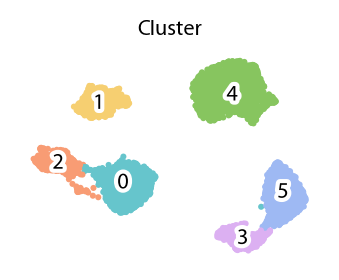

In [ ]:
margin_right = 0

fig_width = margin_left + plot_width_in + margin_right
fig_height = margin_bottom + plot_height_in + margin_top

fig, axes = plt.subplots(figsize=(fig_width, fig_height), dpi=200, layout="constrained")
embedding_shuffled(
    gd_lc_cleaned,
    basis="X_umap",
    color="leiden",
    palette=leiden_colors,
    ax=axes,
    title="Cluster",
    legend_loc="on data",
    legend_fontsize="medium",
    legend_fontweight="normal",
    size=umap_dot_size,
)

axes.set_position(
    [
        margin_left / fig_width,
        margin_bottom / fig_height,
        plot_width_in / fig_width,
        plot_height_in / fig_height,
    ]
)

for artist in axes.collections:
    artist.set_rasterized(True)

### Timepoint

In [ ]:
gd_lc_cleaned.obs['developmental_stage'] = np.where(gd_lc_cleaned.obs['developmental_stage'] == 'embryo', 'fetal', 'adult')
gd_lc_cleaned.obs['developmental_stage'] = gd_lc_cleaned.obs['developmental_stage'].astype('category').cat.reorder_categories(['fetal', 'adult', ])

/home/david/anaconda3/envs/skin_development/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


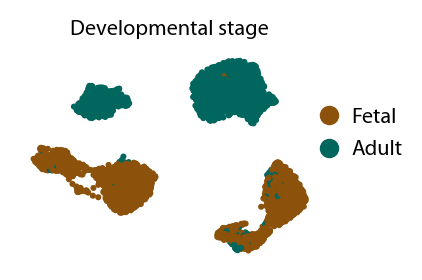

In [ ]:
margin_right = (
    15 / 25.4
)

fig_width = (
    margin_left + plot_width_in + legend_width_in + margin_right
) 
fig_height = margin_bottom + plot_height_in + margin_top

fig, axes = plt.subplots(figsize=(fig_width, fig_height), dpi=200, layout="constrained")
embedding_shuffled(
    gd_lc_cleaned,
    basis="X_umap",
    color="developmental_stage",
    palette=dev_stage_colors,
    ax=axes,
    title="Developmental stage",
    size=umap_dot_size,
)

axes.set_position(
    [
        margin_left / fig_width,
        margin_bottom / fig_height,
        plot_width_in / fig_width,
        plot_height_in / fig_height,
    ]
)

handles, labels = axes.get_legend_handles_labels()
axes.legend_.remove()
fig.legend(
    handles,
    [l.capitalize() for l in labels],
    loc="center left",
    bbox_to_anchor=(0.97 - (margin_right / fig_width), 0.5),
    frameon=False,
)

for artist in axes.collections:
    artist.set_rasterized(True)

### Cell type

/home/david/anaconda3/envs/skin_development/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


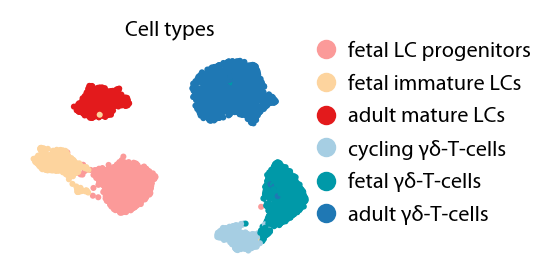

In [ ]:
margin_right = (
    27 / 25.4
)

fig_width = (
    margin_left + plot_width_in + legend_width_in + margin_right
)
fig_height = margin_bottom + plot_height_in + margin_top

fig, axes = plt.subplots(figsize=(fig_width, fig_height), dpi=200, layout="constrained")
embedding_shuffled(
    gd_lc_cleaned,
    basis="X_umap",
    color="cell_type_clean",
    palette=cell_type_colors,
    ax=axes,
    title="Cell types",
    size=umap_dot_size,
)

axes.set_position(
    [
        margin_left / fig_width,
        margin_bottom / fig_height,
        plot_width_in / fig_width,
        plot_height_in / fig_height,
    ]
)

handles, labels = axes.get_legend_handles_labels()
axes.legend_.remove()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.97 - (margin_right / fig_width), 0.5),
    frameon=False,
)

for artist in axes.collections:
    artist.set_rasterized(True)

## Dotplot

### Dotplot

#### LC

<positron-console-cell-130>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<positron-console-cell-130>:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-02-27 10:32:16 | [INFO] maxp pruned
2026-02-27 10:32:16 | [INFO] cmap pruned
2026-02-27 10:32:16 | [INFO] post pruned
2026-02-27 10:32:16 | [INFO] CFF  pruned
2026-02-27 10:32:16 | [INFO] BASE dropped
2026-02-27 10:32:16 | [INFO] DSIG dropped
2026-02-27 10:32:16 | [INFO] GPOS pruned
2026-02-27 10:32:16 | [INFO] GSUB pruned
2026-02-27 10:32:16 | [INFO] Added .notdef to subset
2026-02-27 10:32:16 | [INFO] Closing glyph list over 'GSUB': 31 glyphs before
202

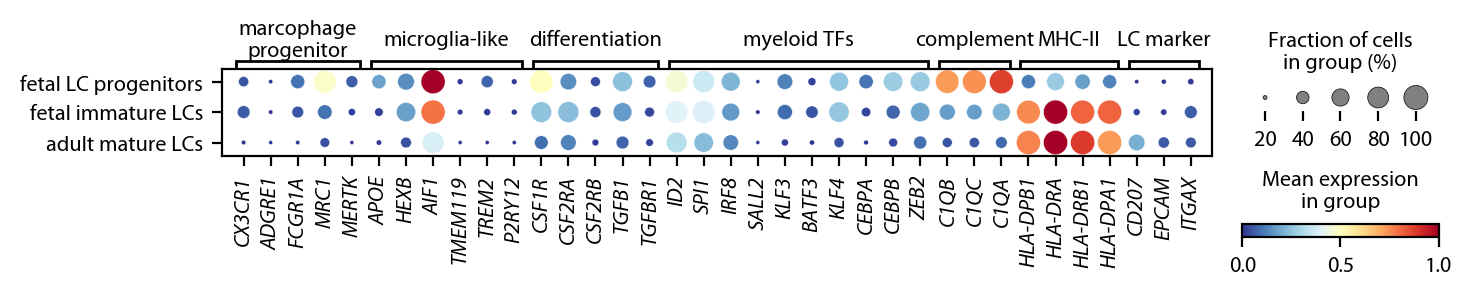

In [ ]:
genes = {
    "marcophage\nprogenitor": ["CX3CR1", "ADGRE1", "FCGR1A", "MRC1", "MERTK"],
    "microglia-like": [
        "APOE",
        "HEXB",
        "AIF1",
        "TMEM119",
        "TREM2",
        "P2RY12",
    ],
    "differentiation": [
        "CSF1R",
        "CSF2RA",
        "CSF2RB",
        "TGFB1",
        "TGFBR1",
    ],
    "myeloid TFs": [
        "ID2",
        "SPI1",
        "IRF8",
        "SALL2",
        "KLF3",
        "BATF3",
        "KLF4",
        "CEBPA",
        "CEBPB",
        "ZEB2",
    ],
    "complement": [
        "C1QB",
        "C1QC",
        "C1QA",
    ],
    "MHC-II": [
        "HLA-DPB1",
        "HLA-DRA",
        "HLA-DRB1",
        "HLA-DPA1",
    ],
    "LC marker": [
        "CD207",
        "EPCAM",
        "ITGAX",
    ],
}

order_cluster = ["fetal LC progenitors", "fetal immature LCs", "adult mature LCs",]

fig, ax_dotplot = plot_dotplot(
    gd_lc_cleaned[gd_lc_cleaned.obs['cell_group'] == 'LC'],
    genes=genes,
    groupby="cell_type_clean",
    categories_order=order_cluster,
    swap_axes=False,
    figsize=(184 / 25.4, 35 / 25.4),
    dot_sizes=(2, 75),
    legend_size=(1.2, 0.7),
    legend_wspace=0.01,
    margin_dotplot=(-0.025, 0.15),
    var_group_brackets_size = (0.33,0.58),
    gs_dotplot_height_ratios=[0.01, 0.9, 0.1],
)

fig.subplots_adjust(left=0.14, right=1, bottom=0.41, top=0.78)
fig.set_layout_engine('constrained')

#### gdT

<positron-console-cell-132>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<positron-console-cell-132>:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-02-27 10:34:04 | [INFO] maxp pruned
2026-02-27 10:34:04 | [INFO] cmap pruned
2026-02-27 10:34:04 | [INFO] post pruned
2026-02-27 10:34:04 | [INFO] CFF  pruned
2026-02-27 10:34:04 | [INFO] BASE dropped
2026-02-27 10:34:04 | [INFO] DSIG dropped
2026-02-27 10:34:04 | [INFO] GPOS pruned
2026-02-27 10:34:04 | [INFO] GSUB pruned
2026-02-27 10:34:04 | [INFO] Added .notdef to subset
2026-02-27 10:34:04 | [INFO] Closing glyph list over 'GSUB': 29 glyphs before
202

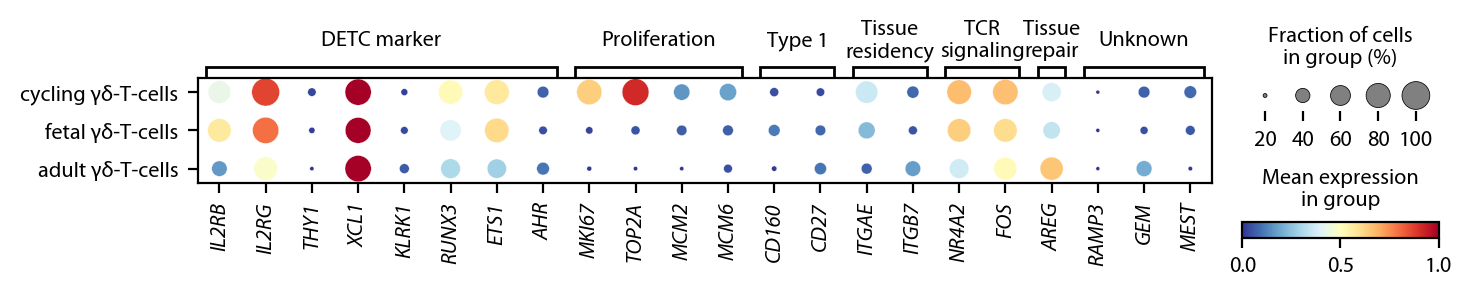

In [ ]:
genes = {
    "DETC marker": [
        "IL2RB",
        "IL2RG",
        "THY1",
        "XCL1",
        "KLRK1",
        "RUNX3",
        "ETS1",
        "AHR",
    ],
    "Proliferation": [
        "MKI67",
        "TOP2A",
        "MCM2",
        "MCM6",
    ],
    "Type 1": [
        "CD160",
        "CD27",
    ],
    "Tissue\nresidency": [
        "ITGAE",
        "ITGB7",
    ],
    "TCR\nsignaling": [
        "NR4A2",
        "FOS",
    ],
    "Tissue\nrepair": [
        "AREG",
    ],
    "Unknown": [
        "RAMP3",
        "GEM",
        "MEST",
    ],
}

order_cluster = ["cycling γδ-T-cells", "fetal γδ-T-cells", "adult γδ-T-cells"]

fig, ax_dotplot = plot_dotplot(
    gd_lc_cleaned[gd_lc_cleaned.obs["cell_group"] == "γδ-T-cells"],
    genes=genes,
    groupby="cell_type_clean",
    categories_order=order_cluster,
    swap_axes=False,
    figsize=(184 / 25.4, 35 / 25.4),
    dot_sizes=(2, 100),
    legend_size=(1.2, 0.9),
    legend_wspace=0.05,
    margin_dotplot=(-0.025, 0.12),
    gs_dotplot_height_ratios=[0.01, 0.9, 0.1],
)

fig.subplots_adjust(left=0.14, right=1, bottom=0.41, top=0.78)
fig.set_layout_engine('constrained')

## Dotplot top 5

In [ ]:
sc.tl.rank_genes_groups(gd_lc_cleaned, groupby='leiden', method='wilcoxon', layer='log1p_norm')

deg_df_leiden = sc.get.rank_genes_groups_df(gd_lc_cleaned, group=None)

<positron-console-cell-80>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<positron-console-cell-80>:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-02-28 19:19:17 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-28 19:19:17 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-28 19:19:18 | [INFO]

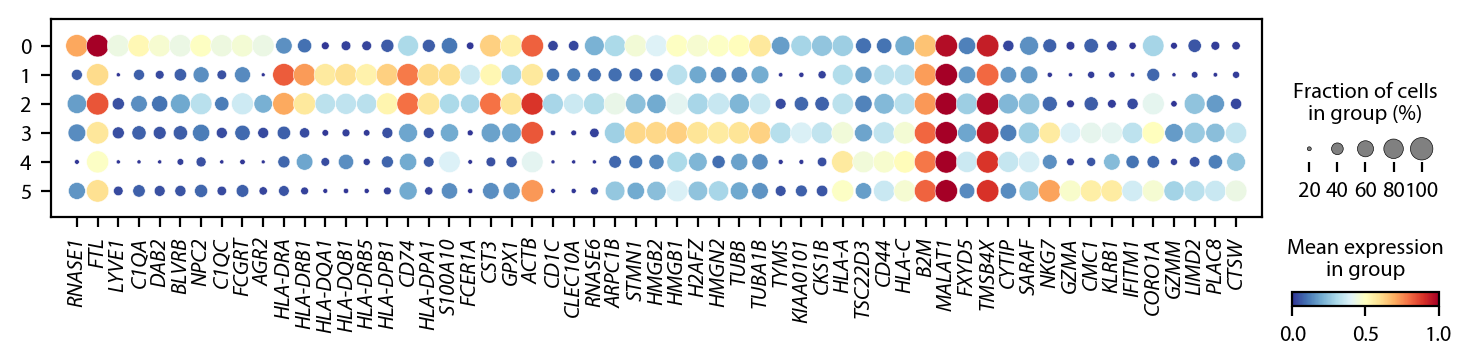

In [ ]:
genes = (
    deg_df_leiden
    .groupby(['group'], observed=True)
    .head(10)
    .loc[:, 'names']
    .unique()
    .tolist()
)

order_cluster = ['0', '1', '2', '3', '4', '5']

fig, ax_dotplot = plot_dotplot(
    gd_lc_cleaned,
    genes=genes,
    groupby="leiden",
    categories_order=order_cluster,
    swap_axes=False,
    figsize=(184 / 25.4, 45 / 25.4),
    dot_sizes=(2, 65),
    legend_size=(0.95, 0.3),
    legend_wspace=0.01,
    margin_dotplot=(-0.025, 0.12),
    gs_dotplot_height_ratios=[0.01, 0.9, 0.1],
)

fig.subplots_adjust(left=0.14, right=1, bottom=0.41, top=0.78)
fig.set_layout_engine('constrained')

## Boxplot gene sets

### gd-T-cells

In [ ]:
df = sc.get.obs_df(gd_lc_cleaned[gd_lc_cleaned.obs['cell_group'] == 'γδ-T-cells'], keys=["developmental_stage", "sample_id"])

df = (
    df.merge(gd_lc_cleaned.obsm["score_aucell"], left_index=True, right_index=True)
    .groupby(["developmental_stage", "sample_id"], observed=True)
    .mean()
    .reset_index()
)

<positron-console-cell-278>:20: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
<positron-console-cell-278>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<positron-console-cell-278>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
2026-02-27 12:35:19 | [INFO] maxp pruned
2026-02-27 12:35:19 | [INFO] cmap pruned
2026-02-27 12:35:19 | [INFO] post pruned
2026-02-27 12:35:19 | [INFO] CFF  pruned
2026-02-27 12:35:19 | [INFO] BASE dropped
2026-02-27 12:35:19 | [INFO] DSIG dropped
2026-02-27 12:35:19 | [INFO] GPOS pruned
2026-02-27 12:35:19 | [INFO] GSUB pruned
2026-02-27 12:35:19 | [INFO] Added .notdef to subset
2026-02-27 12:35:19 | [INFO] Closing glyph list over 'GSUB': 36 glyphs before
2026-02-27 12:35:19 | [INFO] Glyph names: ['

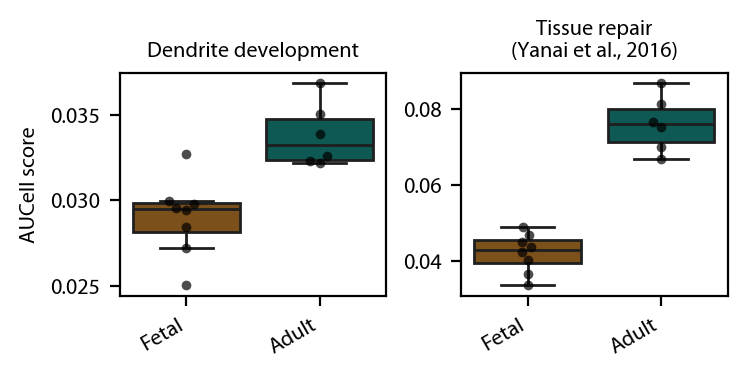

In [ ]:
gene_sets_subset = [
    "GOBP_DENDRITE_DEVELOPMENT",
    "tissue_repair_yanai_2016",
]

gene_set_title = {
    "GOBP_DENDRITE_DEVELOPMENT": "Dendrite development",
    "tissue_repair_yanai_2016": "Tissue repair\n(Yanai et al., 2016)",
}

n_col = min(len(gene_sets_subset), 4)
n_row = int(np.ceil(len(gene_sets_subset) / n_col))

fig = plt.figure(
    figsize=((92/2 / 25.4) * n_col, 45 / 25.4 * n_row),
    dpi=200,
    layout="constrained",
)

plt.subplots_adjust(wspace=0.6)

for gene in gene_sets_subset:
    ax = fig.add_subplot(n_row, n_col, gene_sets_subset.index(gene) + 1)

    sns.boxplot(
        data=df, x="developmental_stage", y=gene, hue="developmental_stage", palette=dev_stage_colors,
        fliersize=0
    )

    sns.swarmplot(data=df, x="developmental_stage", y=gene, color="black", alpha=0.7, size=3.5)

    ax.set_title(
        gene_set_title[gene],
    )

    ax.set_xlabel("")

    if gene_sets_subset.index(gene) == 0:
        ax.set_ylabel("AUCell score")
    else:
        ax.set_ylabel("")

    ax.set_xticklabels(['Fetal', 'Adult'], rotation=30, ha='right')

### LC

In [ ]:
df = sc.get.obs_df(gd_lc_cleaned[gd_lc_cleaned.obs['cell_group'] == 'LC'], keys=["developmental_stage", "sample_id"])

df = (
    df.merge(gd_lc_cleaned.obsm["score_aucell"], left_index=True, right_index=True)
    .groupby(["developmental_stage", "sample_id"], observed=True)
    .mean()
    .reset_index()
)

<positron-console-cell-276>:20: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
<positron-console-cell-276>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<positron-console-cell-276>:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<positron-console-cell-276>:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
2026-02-27 12:35:06 | [INFO] maxp pruned
2026-02-27 12:35:06 | [INFO] cmap pruned
2026-02-27 12:35:06 | [INFO] post pruned
2026-02-27 12:35:06 | [INFO] CFF  pruned
2026-02-27 12:35:06 | [INFO] BASE dropped
2026-02-27 12:35:06 | [INFO] DSIG dropped
2026-02-27 12:35:06 | [INFO] GPOS pruned
2026-02-27 12:35:06 | [INFO] GSUB pruned


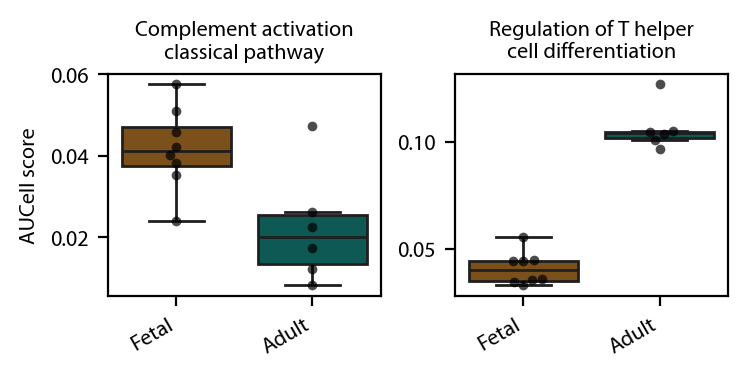

In [ ]:
gene_sets_subset = [
    "GOBP_COMPLEMENT_ACTIVATION_CLASSICAL_PATHWAY",
    "GOBP_REGULATION_OF_T_HELPER_CELL_DIFFERENTIATION", #
]

gene_set_title = {
    "GOBP_COMPLEMENT_ACTIVATION_CLASSICAL_PATHWAY": "Complement activation\nclassical pathway",
    "GOBP_REGULATION_OF_T_HELPER_CELL_DIFFERENTIATION": "Regulation of T helper\ncell differentiation",
}

n_col = min(len(gene_sets_subset), 4)
n_row = int(np.ceil(len(gene_sets_subset) / n_col))

fig = plt.figure(
    figsize=((92/2 / 25.4) * n_col, 45 / 25.4 * n_row),
    dpi=200,
    layout="constrained",
)

plt.subplots_adjust(wspace=0.6)

for gene in gene_sets_subset:
    ax = fig.add_subplot(n_row, n_col, gene_sets_subset.index(gene) + 1)

    sns.boxplot(
        data=df, x="developmental_stage", y=gene, hue="developmental_stage", palette=dev_stage_colors,
        fliersize=0
    )

    sns.swarmplot(data=df, x="developmental_stage", y=gene, color="black", alpha=0.7, size=3.5)

    ax.set_title(
        gene_set_title[gene],
    )

    ax.set_xlabel("")

    if gene_sets_subset.index(gene) == 0:
        ax.set_ylabel("AUCell score")
    else:
        ax.set_ylabel("")

    ax.set_xticklabels(['Fetal', 'Adult'], rotation=30, ha='right')

fig.subplots_adjust(left=0.22, right=0.88, bottom=0.22, top=0.79)

## Boxplot genes

In [ ]:
genes_of_interest = ['IL13', 'IL13RA1', 'TGFB1', 'TGFBR1', 'CSF2', 'CSF2RA']

df = sc.get.obs_df(gd_lc_cleaned, keys=["sample_id", 'cell_group', 'developmental_stage']+ genes_of_interest)

df = (
    df.merge(gd_lc_cleaned.obsm["score_aucell"], left_index=True, right_index=True)
    .groupby(["cell_group", "sample_id", 'developmental_stage'], observed=True)
    .mean()
    .reset_index()
)

<positron-console-cell-309>:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<positron-console-cell-309>:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
2026-02-27 13:25:08 | [INFO] maxp pruned
2026-02-27 13:25:08 | [INFO] cmap pruned
2026-02-27 13:25:08 | [INFO] post pruned
2026-02-27 13:25:08 | [INFO] CFF  pruned
2026-02-27 13:25:08 | [INFO] BASE dropped
2026-02-27 13:25:08 | [INFO] DSIG dropped
2026-02-27 13:25:08 | [INFO] GPOS pruned
2026-02-27 13:25:08 | [INFO] GSUB pruned
2026-02-27 13:25:08 | [INFO] Added .notdef to subset
2026-02-27 13:25:08 | [INFO] Closing glyph list over 'GSUB': 14 glyphs before
2026-02-27 13:25:08 | [INFO] Glyph names: ['.notdef', 'A', 'B', 'C', 'F', 'G', 'I', 'L', 'R', 'S', 'T', 'one', 'three', 'two']
2026-02-27 13:25:08 | [INFO] Glyph IDs:   [0, 18, 19, 20, 34, 35, 36, 39, 40, 42, 45, 51, 52

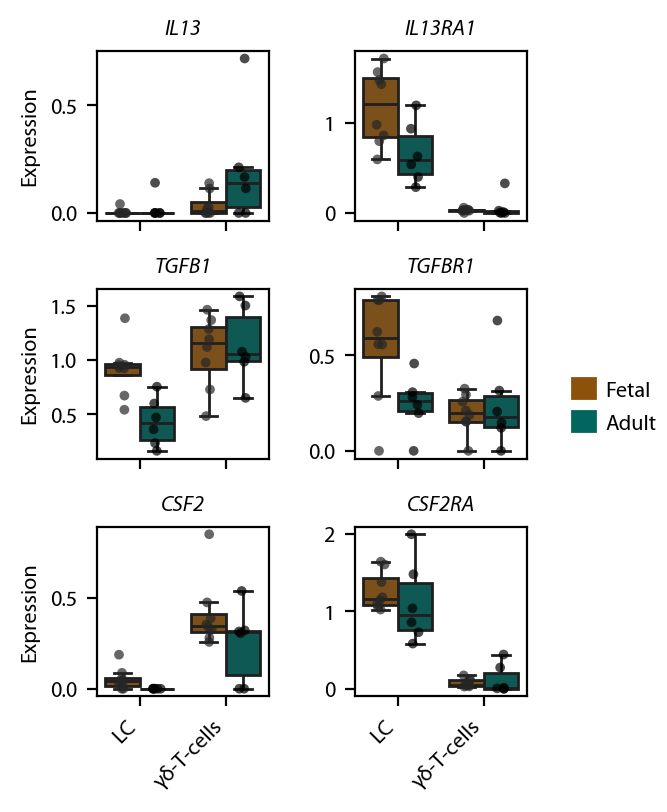

In [ ]:
fig = plt.figure(
    figsize=((84 / 25.4), 100 / 25.4 * n_row),
    dpi=200,
)

gs_boxplots = gridspec.GridSpec(
    nrows=3,
    ncols=2,
    figure=fig,
)

for i, gene in enumerate(genes_of_interest):
    ax = fig.add_subplot(gs_boxplots[i])

    sns.boxplot(
        data=df,
        x="cell_group",
        y=gene,
        hue="developmental_stage",
        palette=dev_stage_colors,
        legend=None,
        fliersize=0,
    )

    sns.stripplot(
        data=df,
        x="cell_group",
        y=gene,
        hue="developmental_stage",
        palette="dark:black",
        alpha=0.7,
        size=3.5,
        legend=None,
        dodge=True,
    )

    ax.set_title(gene, style="italic")

    ax.set_xlabel("")

    if i in [0, 2, 4]:
        ax.set_ylabel(
            "Expression",
        )
    else:
        ax.set_ylabel("")

    if i < 4:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

dev_stage_patches = [
    mpatches.Patch(color=color, label=label.capitalize())
    for label, color in dev_stage_colors.items()
]

fig.legend(
    handles=(dev_stage_patches),
    title=None,
    loc="center right",
    frameon=False,
)

fig.subplots_adjust(left=0.15, right=0.8, bottom=0.13, top=0.95, wspace=0.5, hspace=0.4)